In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor
)
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading

In [2]:
df = pd.read_csv('D:\\Python Programing\\Python Practice\\Demos\\House price prediiction\\Datasets\\Ready for ML_production_Pipline.csv')

## 2. Target Preparation

In [3]:
leak_cols = ['Price (in rupees)', 'Amount_numeric', 'price_log', 'Sqrt_Area']
X = df.drop(columns=leak_cols)
y = df['price_log']


## 3. Train/Test Split

In [4]:
# This is the ONLY place in the whole workflow that splits the data.
# Data_Preprocessing.ipynb only cleans; it doesn't split or encode, so there's
# no risk of two notebooks disagreeing on the split or double-encoding a
# column (the bug from the previous version).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


### 3.1 Custome Frequnecy encoder 

In [5]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
  
    def __init__(self):
        self.freq_maps = {}   # stores {column_name: {category: frequency}}
        self.columns_ = None  # stores column names seen during fit

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.columns_ = X.columns.tolist()

        for col in self.columns_:
            # calculate frequency (proportion) of each category in training data
            self.freq_maps[col] = X[col].value_counts(normalize=True).to_dict()

        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns_).copy()

        for col in self.columns_:
            X[col] = X[col].map(self.freq_maps[col]).fillna(0)

        return X.values

    def get_feature_names_out(self, input_features=None):
        # needed so ColumnTransformer / pipelines can properly name output columns
        return [f"{col}_freq" for col in self.columns_]

## 4. Preprocessing Pipeline

- Numeric features: median imputation + standard scaling.
- Categorical features: most-frequent imputation + one-hot encoding (unknown categories at
  inference time are ignored rather than raising an error).
- Categorical features:`Locaation` Frequency encoder + standard scaling.

All fit exclusively on the training fold to avoid leakage; wrapped in `ColumnTransformer` +
`Pipeline` so the exact same transform is reapplied to validation/test/production data.


In [6]:
num_features = ['Sqrt_Area_transform','total_floors','current_floor','Bathroom', 'Balcony']

# BUGFIX: these used to be the *already one-hot-encoded* column names
# (e.g. 'Transaction_Resale'), because the preprocessing notebook was
# encoding them and this ColumnTransformer was encoding them a second time.
# Now that the preprocessing notebook saves raw categoricals, this
# ColumnTransformer is the only place encoding happens.
cat_features = ['overlook_garden', 'overlook_mainroad', 'overlook_pool',
       'Transaction', 'Furnishing', 'facing', 'Ownership']

# BUGFIX: 'location' used to arrive here already frequency-encoded (a float)
# from the preprocessing notebook, so FrequencyEncoder was computing a
# "frequency of a frequency". It now arrives as the raw location string.
freq_features = ['location']

preprocessor = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                    ('scale', StandardScaler())]), num_features),

    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                    ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_features),

     ('freq', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                     ('freq_enc', FrequencyEncoder())]), freq_features),
])

preprocessor


,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 5. Model Selection

In [7]:
models = {
    'XG_boost':XGBRegressor(),
    "Linear Regression": LinearRegression(),
    "KNN": KNeighborsRegressor(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)   

results = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='r2')  
    results[name] = (scores.mean(), scores.std())
    print(f'{name:28s} R2: {scores.mean():.3f} +/- {scores.std():.3f}')

results_df = pd.Series({k: v[0] for k, v in results.items()}).sort_values(ascending=True)
results_df

XG_boost                     R2: 0.924 +/- 0.003
Linear Regression            R2: 0.665 +/- 0.001
KNN                          R2: 0.838 +/- 0.002
Ridge                        R2: 0.665 +/- 0.001
Lasso                        R2: -0.000 +/- 0.000
Decision Tree                R2: 0.859 +/- 0.004
Random Forest                R2: 0.925 +/- 0.002


Lasso               -0.000051
Ridge                0.665365
Linear Regression    0.665366
KNN                  0.837596
Decision Tree        0.858587
XG_boost             0.924224
Random Forest        0.924965
dtype: float64

| Model | R2-Score | Std |
|---|---|---|
| `XG_boost ` | 0.924  | 0.002 |
| `Linear Regression` | 0.670 | 0.001 |
| `KNN` | 0.833 | 0.002 |
| `Ridge` | 0.670 | 0.001|
| `Lasso` | -0.000 | 0.000 |
| `Decision Tree` | 0.855 | 0.003|
| `Random Forest` | 0.924 | 0.002 |
| `Extra Trees` | 0.914 | 0.002 |
| `Gradient Boosting` | 0.835 | 0.003 |
| `AdaBoost` | 0.600 | 0.014 |


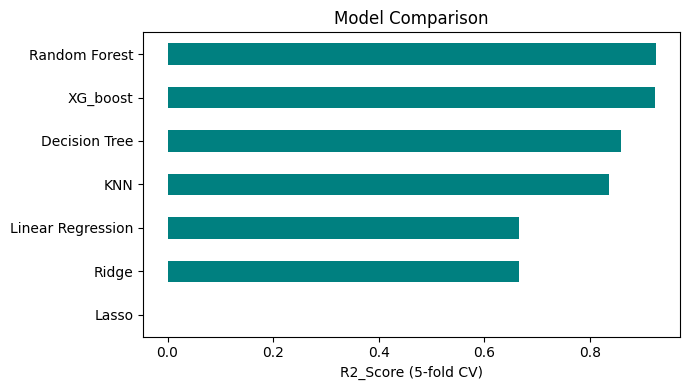

Best model: Lasso


In [8]:
fig, ax = plt.subplots(figsize=(7,4))
results_df.plot(kind='barh', ax=ax, color='teal')
ax.set_title('Model Comparison')
ax.set_xlabel('R2_Score (5-fold CV)')
plt.tight_layout()
plt.show()

best_name = results_df.index[0]
print('Best model:', best_name)


## 7. Model Evaluation on Held-Out Test Set

In [9]:
# NOTE: use clone(preprocessor) here, not the raw `preprocessor` object.
# `preprocessor` was already fit 7x inside the model-comparison loop above.
# Reusing that same fitted instance re-fits FrequencyEncoder on data that
# was already frequency-encoded from a prior fit (frequencies-of-frequencies),
# corrupting the location lookup so every location silently maps to 0 at
# inference time. clone() gives a fresh, unfitted copy of the same structure.
best_pipe = Pipeline([('prep', clone(preprocessor)), ('clf', models['XG_boost'])])
best_pipe.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [10]:
# Predictions (log scale)
y_predict = best_pipe.predict(X_test)
print("R2_score: ", round(r2_score(y_test, y_predict), 3))

R2_score:  0.927


## 7.1 Covert price to actual scale

In [11]:
# ---------- Convert back to real rupees ----------
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_predict)

mae_real = mean_absolute_error(y_test_real, y_pred_real)
rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print(f"MAE (₹): {mae_real:,.0f}")
print(f"RMSE (₹): {rmse_real:,.0f}")

MAE (₹): 1,183,472
RMSE (₹): 3,592,610


In [12]:
xgb_model = best_pipe.named_steps['clf']
feature_names = best_pipe.named_steps['prep'].get_feature_names_out()

importances = pd.Series(xgb_model.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

print(importances.head(15))

num__Bathroom                      0.584631
num__Sqrt_Area_transform           0.056106
freq__0_freq                       0.054269
num__total_floors                  0.035990
cat__Transaction_Resale_0          0.028290
cat__facing_Unknown_0              0.026706
cat__overlook_garden_0             0.024375
cat__Ownership_Leasehold_0         0.019923
cat__Transaction_New Property_0    0.017572
cat__overlook_mainroad_0           0.016840
cat__Furnishing_Unfurnished_0      0.014849
num__Balcony                       0.012890
cat__facing_South - East_0         0.011979
cat__facing_East_0                 0.011164
cat__Furnishing_Furnished_0        0.011083
dtype: float32


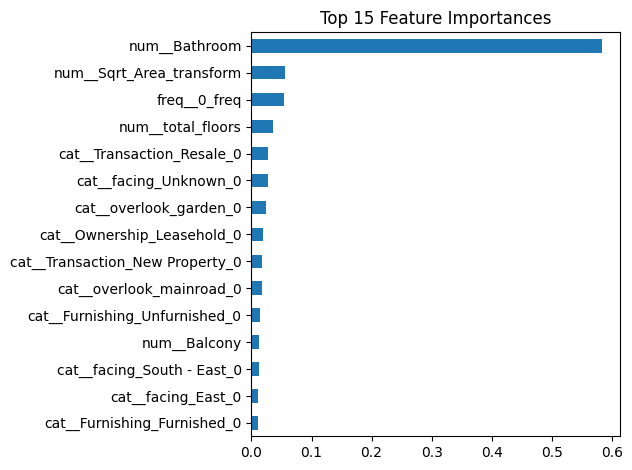

In [13]:
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

## 9. Cross-Validation Summary (Final Model)

In [14]:
# ---------- Final cross-validation check on best pipeline ----------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

final_scores = cross_val_score(best_pipe, X_train, y_train, cv=cv, scoring='r2')
print(f"Final CV R2: {final_scores.mean():.3f} +/- {final_scores.std():.3f}")
print("Individual fold scores:", final_scores)

Final CV R2: 0.924 +/- 0.003
Individual fold scores: [0.9257058  0.92146438 0.92809768 0.92149044 0.92435947]


In [15]:
# ---------- Fit on FULL training data before saving (already done, but confirm) ----------
best_pipe.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 10. Model Serialization

In [16]:
joblib.dump(best_pipe, 'D:\Python Programing\Python Practice\Demos\House price prediiction\Model\house_price_xgb_pipeline.pkl')
print("Model saved to house_price_xgb_pipeline.pkl")

Model saved to house_price_xgb_pipeline.pkl
